# Quasi-Phase Matching via Periodic Poling in LiNbO$_3$
## Merged Analysis: Domain Modeling, Higher-Order QPM, Duty-Cycle Effects, and BPM Comparison

**Course:** UE23EC343BB2 &nbsp;|&nbsp; Orange / Jackfruit Problem
**Primary reference:** Yesharim *et al.*, *Appl. Phys. Rev.* **12**, 011323 (2025)

---

### What this notebook covers

| # | Section | Key output |
|---|---------|-----------|
| 1 | Crystal material library (extensible) | Sellmeier $n(\lambda)$, $d_{ij}$ coefficients |
| 2 | Wavelength config & phase-mismatch | $\Delta k$, coherence length $L_c$, QPM period $\Lambda$ |
| 3 | Core functions | Analytical + numerical coupling integral |
| 4 | Pedagogical $\eta$ vs $L$ | Sinc$^2$ at different $\Delta k$ |
| 5 | Realistic sub-micron oscillations | Why QPM is mandatory |
| 6 | Periodic poling profile $d(z)$ | Square-wave construction |
| 7 | Numerical $(2/\pi)^2$ verification | Fourier theory confirmed from first principles |
| 8 | Coupling integral spectrum | QPM resonance peak |
| 9 | Fourier spectrum of $d(z)$ | All odd orders of QPM |
| 10 | **Duty-cycle dependence** | Why D = 0.5 is optimal |
| 11 | **Higher-order QPM** | $m = 1, 3, 5$ efficiency tradeoffs |
| 12 | BPM vs QPM vs No-PM efficiency | Three-way comparison, $\sim 16\times$ gain |
| 13 | $d_{\rm eff}$ bar chart | BPM vs QPM orders at a glance |
| 14 | Acceptance bandwidth | Spectral selectivity |
| 15 | 2-D phase-space map | $\eta(\Delta k, L)$ landscape |

> **Extensibility:** To add a new crystal, add an entry to the `CRYSTALS` dictionary in Section 2 and change `ACTIVE_CRYSTAL`. All downstream computations adapt automatically.


## 1 &nbsp; Imports & Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

c = 3e8  # speed of light (m/s)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print("Environment ready.")

Environment ready.


## 2 &nbsp; Crystal Material Library (Extensible)

Each crystal is defined by:

| Key | Meaning |
|-----|---------|
| `sellmeier` | Function $n(\lambda)$, wavelength in **metres** |
| `d33` | Largest diagonal $\chi^{(2)}$ element (pm/V) -- used in QPM |
| `d31` | Off-diagonal element (pm/V) -- forced by birefringent PM |
| `label` | Display name |

Currently active: **LiNbO$_3$ (ordinary axis, Zelmon 1997)**

> **To add a material** (KTP, BBO, LiTaO$_3$, etc.): append to `CRYSTALS` with the four keys, then set `ACTIVE_CRYSTAL`. Everything re-computes automatically.


In [2]:
def _sellmeier_linbo3(lam_m):
    """LiNbO3 ordinary axis -- Zelmon (1997)."""
    l2 = (lam_m * 1e6) ** 2
    return np.sqrt(4.9048 + 0.11775 / (l2 - 0.04751) - 0.027169 * l2)


# --- Example: uncomment to add KTP ---
# def _sellmeier_ktp(lam_m):
#     """KTP z-axis -- Kato (2002)."""
#     l2 = (lam_m * 1e6) ** 2
#     return np.sqrt(3.3134 + 0.04140 / (l2 - 0.04597) - 0.01682 * l2)


CRYSTALS = {
    "LiNbO3": {
        "sellmeier": _sellmeier_linbo3,
        "d33": 27.0,     # pm/V
        "d31": 4.3,      # pm/V
        "label": r"LiNbO$_3$ (ordinary axis)",
    },
    # --- Uncomment to enable KTP ---
    # "KTP": {
    #     "sellmeier": _sellmeier_ktp,
    #     "d33": 16.9,
    #     "d31": 2.5,
    #     "label": r"KTP ($z$-axis)",
    # },
}

# === CHANGE THIS TO SWITCH MATERIAL ===
ACTIVE_CRYSTAL = "LiNbO3"

xtal  = CRYSTALS[ACTIVE_CRYSTAL]
n_fn  = xtal["sellmeier"]
d33   = xtal["d33"]
d31   = xtal["d31"]
label = xtal["label"]

print(f"Active crystal : {ACTIVE_CRYSTAL}")
print(f"  Display name : {label}")
print(f"  d_33         : {d33} pm/V")
print(f"  d_31         : {d31} pm/V")

Active crystal : LiNbO3
  Display name : LiNbO$_3$ (ordinary axis)
  d_33         : 27.0 pm/V
  d_31         : 4.3 pm/V


## 3 &nbsp; Wavelength Configuration & Phase-Mismatch Calculation

Degenerate type-0 collinear SPDC:
$$\omega_p = \omega_s + \omega_i, \qquad \lambda_s = \lambda_i = 2\lambda_p$$

Phase mismatch:
$$\Delta k = k_p - k_s - k_i = \frac{2\pi}{\lambda_p}n_p - \frac{2\pi}{\lambda_s}n_s - \frac{2\pi}{\lambda_i}n_i$$

Coherence length (max length before destructive interference):
$$L_c = \frac{\pi}{|\Delta k|}$$

QPM period needed to cancel $\Delta k$:
$$\Lambda = \frac{2\pi}{|\Delta k|}$$


In [3]:
# --- Wavelengths (change for non-degenerate SPDC) ---
lambda_p = 405e-9      # pump (m)
lambda_s = 810e-9      # signal (m)
lambda_i = 810e-9      # idler (m)

# Refractive indices
n_p = float(n_fn(lambda_p))
n_s = float(n_fn(lambda_s))
n_i = float(n_fn(lambda_i))

# Wave vectors
k_p = n_p * 2 * np.pi / lambda_p
k_s = n_s * 2 * np.pi / lambda_s
k_i = n_i * 2 * np.pi / lambda_i

# Phase mismatch & coherence length
delta_k_raw = k_p - k_s - k_i
L_c         = np.pi / abs(delta_k_raw)

# QPM period
Lambda_QPM  = 2 * np.pi / abs(delta_k_raw)
G1          = 2 * np.pi / Lambda_QPM
delta_k_qpm = delta_k_raw - G1

print(f"Phase Matching Parameters -- {ACTIVE_CRYSTAL}")
print(f"  lambda_p         : {lambda_p*1e9:.1f} nm")
print(f"  lambda_s = _i    : {lambda_s*1e9:.1f} nm")
print(f"  n_p / n_s / n_i  : {n_p:.4f} / {n_s:.4f} / {n_i:.4f}")
print(f"  k_p              : {k_p:.4e} rad/m")
print(f"  k_s + k_i        : {k_s+k_i:.4e} rad/m")
print(f"  Delta_k (raw)    : {delta_k_raw:.4e} rad/m")
print(f"  L_c              : {L_c*1e6:.2f} um")
print(f"  Lambda_QPM       : {Lambda_QPM*1e6:.2f} um")
print(f"  Delta_k (QPM)    : {delta_k_qpm:.2e} rad/m  (approx 0)")

Phase Matching Parameters -- LiNbO3
  lambda_p         : 405.0 nm
  lambda_s = _i    : 810.0 nm
  n_p / n_s / n_i  : 2.4312 / 2.2540 / 2.2540
  k_p              : 3.7718e+07 rad/m
  k_s + k_i        : 3.4968e+07 rad/m
  Delta_k (raw)    : 2.7500e+06 rad/m
  L_c              : 1.14 um
  Lambda_QPM       : 2.28 um
  Delta_k (QPM)    : 0.00e+00 rad/m  (approx 0)


## 4 &nbsp; Core Functions

Five reusable functions:

1. **`sinc2(x)`** -- safe sinc$^2$ (handles $x=0$)
2. **`eta(dk, L, d)`** -- normalised efficiency $d^2 \cdot L^2 \cdot \mathrm{sinc}^2(\Delta k L/2)$
3. **`build_poling_profile(L, Λ, Nz, duty)`** -- square-wave $d(z) = \pm 1$ with configurable duty cycle
4. **`numerical_coupling_integral(z, d_z, dk)`** -- numerically evaluates $|\Phi|^2/L^2$
5. **`fourier_coeff(m, duty)`** -- $m$-th Fourier coefficient of the binary square wave

The phase-matching integral we evaluate:

$$\Phi(\Delta k) = \int_0^L d(z)\, e^{i\Delta k\, z}\, dz$$


In [4]:
def sinc2(x):
    """Safe sinc^2 -- handles x=0 -> 1."""
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(np.abs(x) < 1e-12, 1.0, (np.sin(x) / x) ** 2)


def eta(dk, L, d):
    """Normalised SPDC efficiency: d^2 * L^2 * sinc^2(dk*L/2)."""
    return d**2 * L**2 * sinc2(dk * L / 2)


def build_poling_profile(L, Lambda, Nz=50000, duty=0.5):
    """
    Construct the binary square-wave poling profile d(z).
    duty : fraction of each period spent in +d33 state (default 0.5)
    """
    z     = np.linspace(0, L, Nz)
    phase = np.mod(z, Lambda) / Lambda
    d_z   = np.where(phase < duty, +1.0, -1.0)
    return z, d_z


def numerical_coupling_integral(z, d_z, dk):
    """
    Numerically evaluate |Phi(dk)|^2 / L^2.
    Perfect PM with d(z)=1 gives 1.0.
    QPM square wave gives (2/pi)^2 approx 0.405.
    """
    L         = z[-1] - z[0]
    integrand = d_z * np.exp(1j * dk * z)
    Phi       = np.trapezoid(integrand, z)
    return (np.abs(Phi) / L) ** 2


def numerical_eta_vs_dk(z, d_z, dk_array):
    """Sweep dk and return |Phi|^2/L^2 at each value."""
    return np.array([numerical_coupling_integral(z, d_z, dk) for dk in dk_array])


def fourier_coeff(m, duty=0.5):
    """
    m-th Fourier coefficient of binary +/-1 square wave with given duty cycle.
    For duty=0.5: gives (2/(m*pi)) for odd m, 0 for even m.
    """
    if m == 0:
        return 2 * duty - 1
    return (2 / (m * np.pi)) * np.sin(m * np.pi * duty)


print("Functions defined: sinc2, eta, build_poling_profile,")
print("                   numerical_coupling_integral, fourier_coeff")

Functions defined: sinc2, eta, build_poling_profile,
                   numerical_coupling_integral, fourier_coeff


## 5 &nbsp; Pedagogical $\eta$ vs Crystal Length

Four scenarios at mm scale (normalised to perfect PM):

| Curve | $\Delta k$ | Meaning |
|-------|-----------|---------|
| Red | 0 | Perfect PM -- $\eta \propto L^2$ |
| Orange | 100 rad/m | Nearly matched -- slow roll-off |
| Blue | 5000 rad/m | Moderate mismatch -- oscillates with period $2L_c$ |
| Green | $\approx 0$ | QPM-compensated -- overlaps perfect PM |


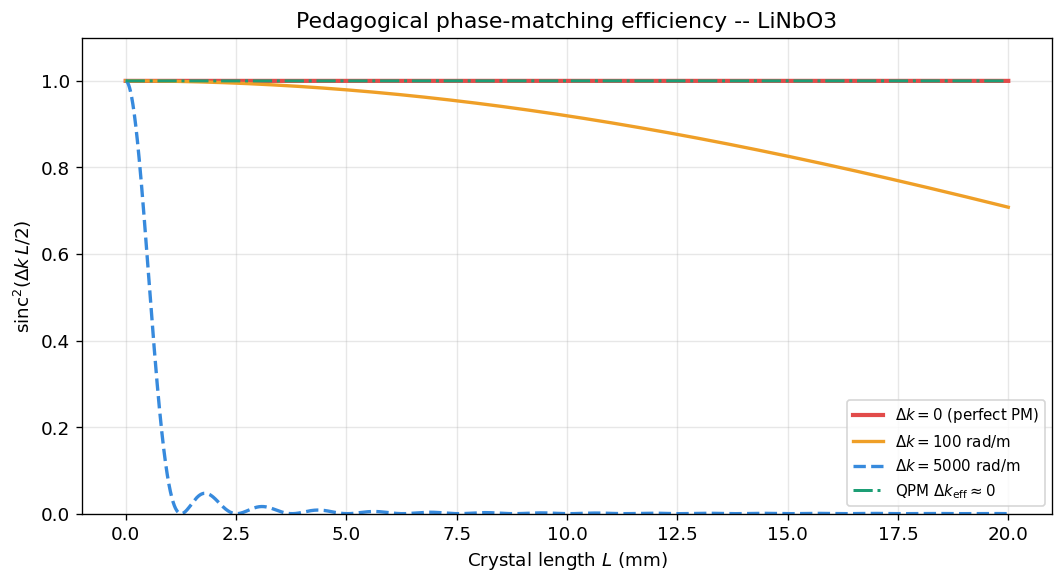

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
L_mm = np.linspace(0, 20e-3, 8000)

# Normalise by L^2 at L=20 mm for display
norm = (20e-3)**2

ax.plot(L_mm*1e3, sinc2(0*L_mm/2),             lw=2.5, color="#E24B4A",
        label=r"$\Delta k=0$ (perfect PM)")
ax.plot(L_mm*1e3, sinc2(1e2*L_mm/2),           lw=2,   color="#EF9F27",
        label=r"$\Delta k=100$ rad/m")
ax.plot(L_mm*1e3, sinc2(5e3*L_mm/2),           lw=2,   color="#378ADD", ls="--",
        label=r"$\Delta k=5000$ rad/m")
ax.plot(L_mm*1e3, sinc2(delta_k_qpm*L_mm/2),   lw=1.8, color="#1D9E75", ls="-.",
        label=r"QPM $\Delta k_{\rm eff} \approx 0$")

ax.set_xlabel("Crystal length $L$ (mm)")
ax.set_ylabel(r"$\mathrm{sinc}^2(\Delta k\, L/2)$")
ax.set_title(f"Pedagogical phase-matching efficiency -- {ACTIVE_CRYSTAL}")
ax.set_ylim(0, 1.10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 &nbsp; Realistic $\Delta k$ -- Sub-Micron Coherence

At the actual dispersion-induced $\Delta k \approx 2.75 \times 10^6$ rad/m, sinc$^2$ oscillates on a micrometre scale. The coherence length $L_c \approx 1.14\;\mu$m means useful pair generation dies within the first micron -- this is *why* QPM is mandatory.


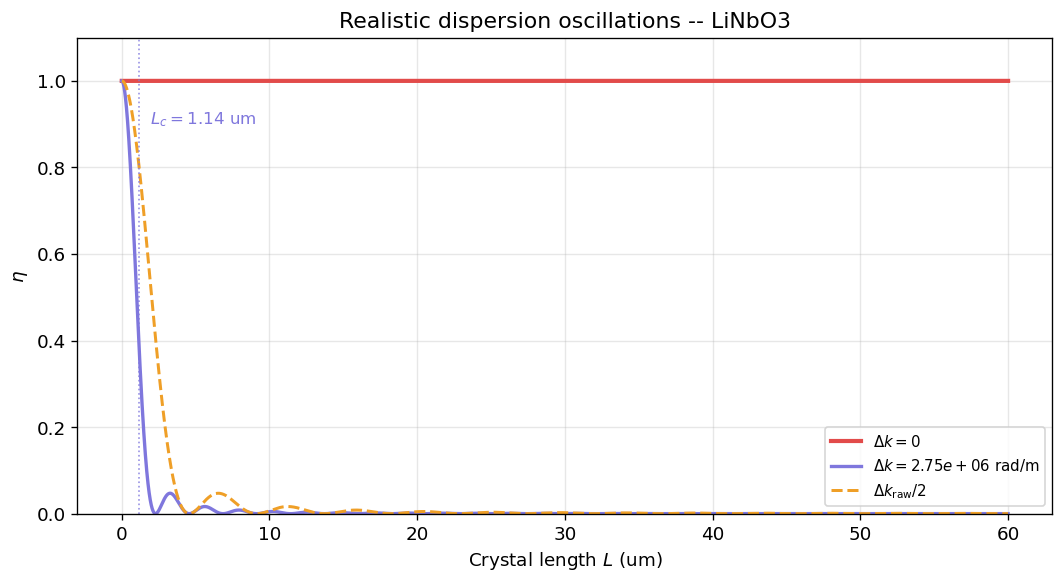

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
L_um = np.linspace(0, 60e-6, 10000)

ax.plot(L_um*1e6, sinc2(0*L_um/2),             lw=2.5, color="#E24B4A",
        label=r"$\Delta k = 0$")
ax.plot(L_um*1e6, sinc2(delta_k_raw*L_um/2),   lw=2,   color="#7F77DD",
        label=f"$\\Delta k = {delta_k_raw:.2e}$ rad/m")
ax.plot(L_um*1e6, sinc2(delta_k_raw/2*L_um/2), lw=1.8, color="#EF9F27", ls="--",
        label=r"$\Delta k_{\rm raw}/2$")

ax.axvline(L_c*1e6, color="#7F77DD", lw=1, ls=":", alpha=0.8)
ax.text(L_c*1e6 + 0.8, 0.90, f"$L_c = {L_c*1e6:.2f}$ um", color="#7F77DD", fontsize=10)

ax.set_xlabel("Crystal length $L$ (um)")
ax.set_ylabel(r"$\eta$")
ax.set_title(f"Realistic dispersion oscillations -- {ACTIVE_CRYSTAL}")
ax.set_ylim(0, 1.10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7 &nbsp; Constructing the Periodic Poling Profile

We explicitly build $d(z) = \mathrm{sign}[\cos(2\pi z/\Lambda)]$ with 50% duty cycle. Each half-period $\Lambda/2$ is one domain; the sign flips compensate the accumulated phase mismatch every coherence length.

This is the physical reality of **electric-field-poled** ferroelectric crystals -- alternating regions of $+\chi^{(2)}$ and $-\chi^{(2)}$ created by applying a high-voltage pulse through structured electrodes.


Crystal length : 200 um
QPM period     : 2.28 um
Domains        : ~88


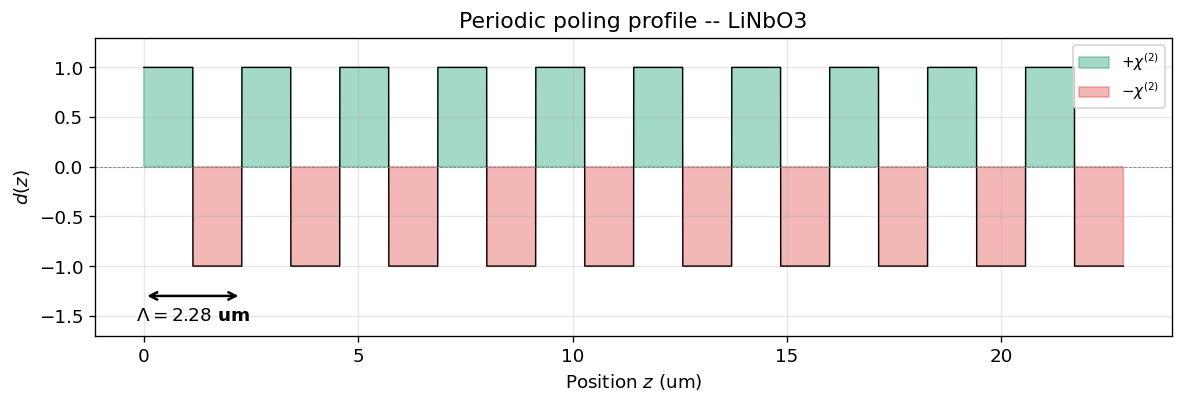

In [7]:
L_crystal = 200e-6    # 200 um -- enough domains to see Fourier structure
Nz        = 100000

z_dom, d_z      = build_poling_profile(L_crystal, Lambda_QPM, Nz, duty=0.5)
d_z_uniform     = np.ones_like(z_dom)
n_domains       = int(np.round(L_crystal / Lambda_QPM))

print(f"Crystal length : {L_crystal*1e6:.0f} um")
print(f"QPM period     : {Lambda_QPM*1e6:.2f} um")
print(f"Domains        : ~{n_domains}")

# --- Visualise first 10 domains ---
fig, ax = plt.subplots(figsize=(10, 3.5))
z_show = 10 * Lambda_QPM
mask   = z_dom <= z_show

ax.fill_between(z_dom[mask]*1e6, d_z[mask], 0,
                where=(d_z[mask] > 0), color="#1D9E75", alpha=0.4,
                label=r"$+\chi^{(2)}$")
ax.fill_between(z_dom[mask]*1e6, d_z[mask], 0,
                where=(d_z[mask] < 0), color="#E24B4A", alpha=0.4,
                label=r"$-\chi^{(2)}$")
ax.plot(z_dom[mask]*1e6, d_z[mask], color="black", lw=0.8)
ax.axhline(0, color="gray", lw=0.5, ls="--")

ax.annotate("", xy=(Lambda_QPM*1e6, -1.3), xytext=(0, -1.3),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text(Lambda_QPM*1e6 / 2, -1.55,
        f"$\\Lambda = {Lambda_QPM*1e6:.2f}$ um",
        ha="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Position $z$ (um)")
ax.set_ylabel("$d(z)$")
ax.set_title(f"Periodic poling profile -- {ACTIVE_CRYSTAL}")
ax.set_ylim(-1.7, 1.3)
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## 8 &nbsp; Numerical Verification of the $2/\pi$ Factor

The square-wave $d(z)$ has a Fourier series:

$$d(z) = \sum_{m\;\text{odd}} \frac{4}{m\pi}\sin\!\left(\frac{m\pi}{2}\right) \cos\!\left(\frac{2\pi m z}{\Lambda}\right)$$

First-order ($m = 1$) coefficient: $2/\pi \approx 0.637$. So $|\Phi|^2/L^2$ should peak at $(2/\pi)^2 \approx 0.405$ at the QPM resonance.

We verify this from first principles by integrating $\Phi = \int d(z)\,e^{i\Delta k z}\,dz$ numerically:

| Test | $\Delta k$ | Expected | Meaning |
|------|-----------|----------|---------|
| Uniform $d=1$ | 0 | 1.0 | Perfect PM reference |
| Poled | $\Delta k_{\rm raw}$ | $(2/\pi)^2 = 0.405$ | QPM resonance |
| Poled | 0 | $\approx 0$ | Square wave DC = 0 |


In [8]:
eta_poled_dkraw = numerical_coupling_integral(z_dom, d_z,        delta_k_raw)
eta_uniform_0   = numerical_coupling_integral(z_dom, d_z_uniform, 0.0)
eta_poled_0     = numerical_coupling_integral(z_dom, d_z,        0.0)

print("Numerical Verification")
print("=" * 50)
print(f"  Poled @ dk_raw : {eta_poled_dkraw:.4f}  (expected {(2/np.pi)**2:.4f})")
print(f"  Uniform @ dk=0 : {eta_uniform_0:.4f}  (expected 1.0000)")
print(f"  Poled @ dk=0   : {eta_poled_0:.6f}  (expected ~0)")
print("=" * 50)
print("The 2/pi factor emerges from the numerical integration,")
print("confirming the analytical Fourier decomposition.")

Numerical Verification
  Poled @ dk_raw : 0.4050  (expected 0.4053)
  Uniform @ dk=0 : 1.0000  (expected 1.0000)
  Poled @ dk=0   : 0.000028  (expected ~0)
The 2/pi factor emerges from the numerical integration,
confirming the analytical Fourier decomposition.


## 9 &nbsp; Coupling Integral Spectrum -- QPM Resonance

We sweep $\Delta k$ around $\Delta k_{\rm raw}$ and plot $|\Phi|^2/L^2$ numerically. The poled crystal shows a sinc-shaped peak at $\Delta k = \Delta k_{\rm raw}$ with amplitude $(2/\pi)^2$ -- this is the QPM resonance.

The reciprocal lattice vector $G = 2\pi/\Lambda$ effectively shifts the sinc$^2$ peak from $\Delta k = 0$ (unachievable with dispersion) to $\Delta k = G$ (where $\Delta k_{\rm raw} = G$ by design).


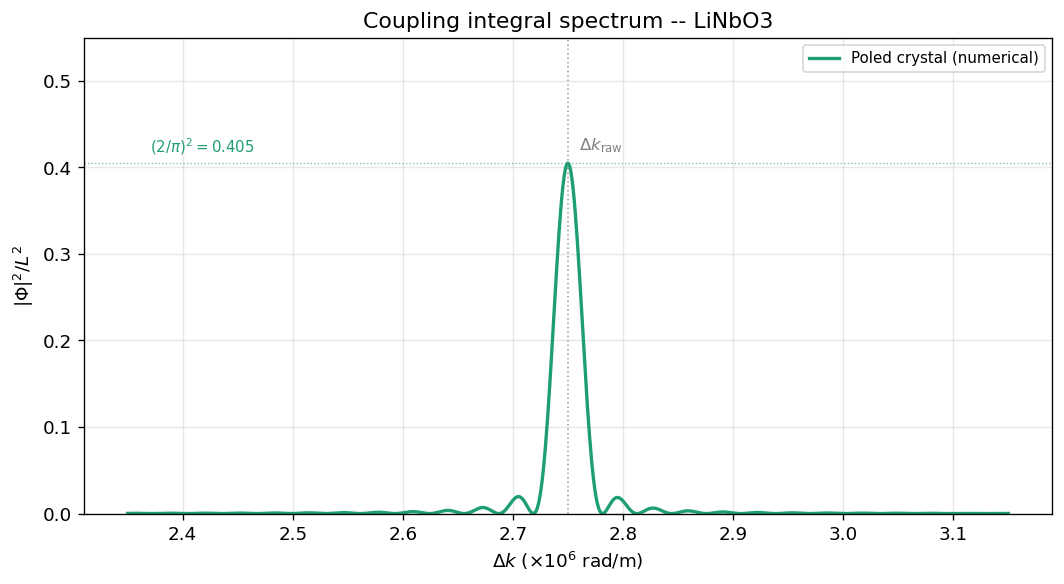

In [9]:
dk_center = delta_k_raw
dk_range  = 4e5
dk_scan   = np.linspace(dk_center - dk_range, dk_center + dk_range, 800)

eta_poled_scan = numerical_eta_vs_dk(z_dom, d_z, dk_scan)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dk_scan * 1e-6, eta_poled_scan, lw=2, color="#1D9E75",
        label="Poled crystal (numerical)")
ax.axvline(delta_k_raw * 1e-6, color="gray", lw=1, ls=":", alpha=0.7)
ax.text(delta_k_raw * 1e-6 + 0.01, 0.42, r"$\Delta k_{\rm raw}$",
        fontsize=10, color="gray")
ax.axhline((2/np.pi)**2, color="#1D9E75", lw=0.8, ls=":", alpha=0.6)
ax.text(dk_scan[0]*1e-6 + 0.02, (2/np.pi)**2 + 0.012,
        f"$(2/\\pi)^2 = {(2/np.pi)**2:.3f}$", fontsize=9, color="#1D9E75")

ax.set_xlabel(r"$\Delta k$ ($\times 10^6$ rad/m)")
ax.set_ylabel(r"$|\Phi|^2 / L^2$")
ax.set_title(f"Coupling integral spectrum -- {ACTIVE_CRYSTAL}")
ax.set_ylim(0, 0.55)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10 &nbsp; Fourier Spectrum of $d(z)$ -- All QPM Orders

The binary square wave contains Fourier components at **odd integer multiples** of $2\pi/\Lambda$. Each of these reciprocal lattice vectors $G_m = m\cdot G_1$ can phase-match a different process -- this is **higher-order QPM**.

For $m$-th order with 50% duty cycle:

$$d_{\rm eff}^{(m)} = \frac{2}{m\pi} d_{33} \quad \text{for odd } m, \quad 0 \text{ for even } m$$

The plot below shows this $1/m$ fall-off.


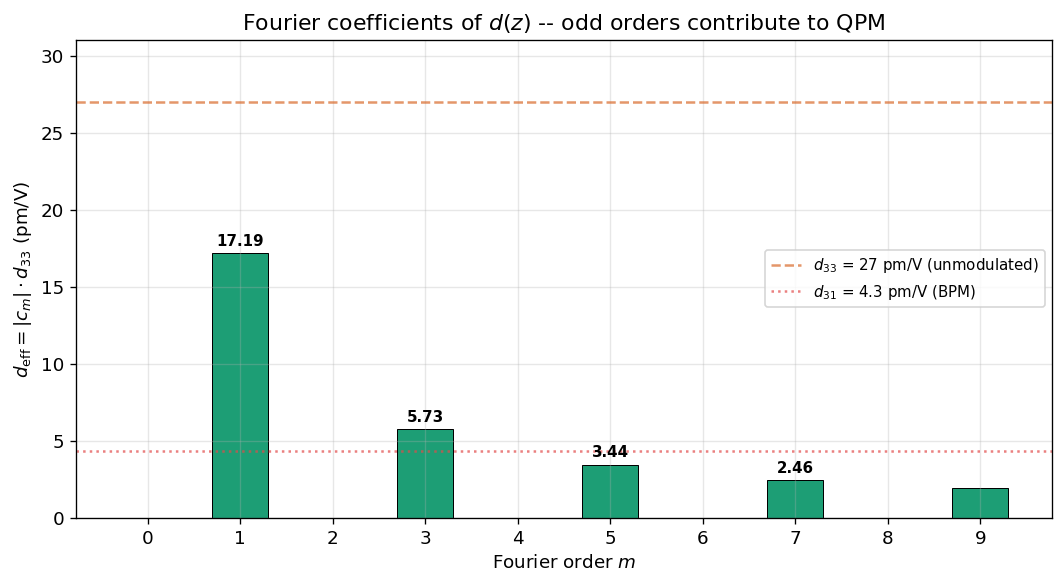


First-order and higher QPM d_eff values:
  m       c_m    d_eff (pm/V)   Lambda_m (um)
  1    0.6366           17.19            2.28
  3   -0.2122            5.73            6.85
  5    0.1273            3.44           11.42
  7   -0.0909            2.46           15.99


In [10]:
m_vals = np.arange(0, 10)
c_m    = np.array([fourier_coeff(m) for m in m_vals])
deff_m = np.abs(c_m) * d33   # effective d_eff for each order (pm/V)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#1D9E75" if (m % 2 == 1) else "#888888" for m in m_vals]
bars = ax.bar(m_vals, deff_m, color=bar_colors, edgecolor="black",
              linewidth=0.6, width=0.6)

# Annotate odd orders
for m in [1, 3, 5, 7]:
    ax.text(m, deff_m[m] + 0.5, f"{deff_m[m]:.2f}",
            ha="center", fontsize=9, fontweight="bold")

ax.axhline(d33, color="#D96A2B", lw=1.5, ls="--", alpha=0.7,
           label=f"$d_{{33}}$ = {d33:.0f} pm/V (unmodulated)")
ax.axhline(d31, color="#E24B4A", lw=1.5, ls=":", alpha=0.7,
           label=f"$d_{{31}}$ = {d31:.1f} pm/V (BPM)")

ax.set_xlabel("Fourier order $m$")
ax.set_ylabel(r"$d_{\rm eff} = |c_m| \cdot d_{33}$ (pm/V)")
ax.set_title(f"Fourier coefficients of $d(z)$ -- odd orders contribute to QPM")
ax.set_xticks(m_vals)
ax.legend(fontsize=9)
ax.set_ylim(0, d33 * 1.15)
plt.tight_layout()
plt.show()

# Print table
print("\nFirst-order and higher QPM d_eff values:")
print(f"{'m':>3}  {'c_m':>8}  {'d_eff (pm/V)':>14}  {'Lambda_m (um)':>14}")
for m in [1, 3, 5, 7]:
    Lambda_m = m * Lambda_QPM  # higher orders use longer periods
    print(f"{m:>3}  {fourier_coeff(m):>8.4f}  {deff_m[m]:>14.2f}  {Lambda_m*1e6:>14.2f}")

## 11 &nbsp; Duty-Cycle Dependence

Real fabricated crystals rarely achieve exactly 50% duty cycle. How much efficiency do we lose?

The $m$-th Fourier coefficient as a function of duty cycle $D$:

$$c_m(D) = \frac{2}{m\pi}\sin(m\pi D)$$

**Observations:**
- **1st order** peaks at $D = 0.5$ with $c_1 = 2/\pi \approx 0.637$
- **3rd order** peaks at $D = 1/6$ and $D = 5/6$ (useful when you need a longer period for fabrication)
- Deviations from 50% are tolerable for 1st-order QPM -- a 10% error in $D$ only costs a few percent in $d_{\rm eff}$


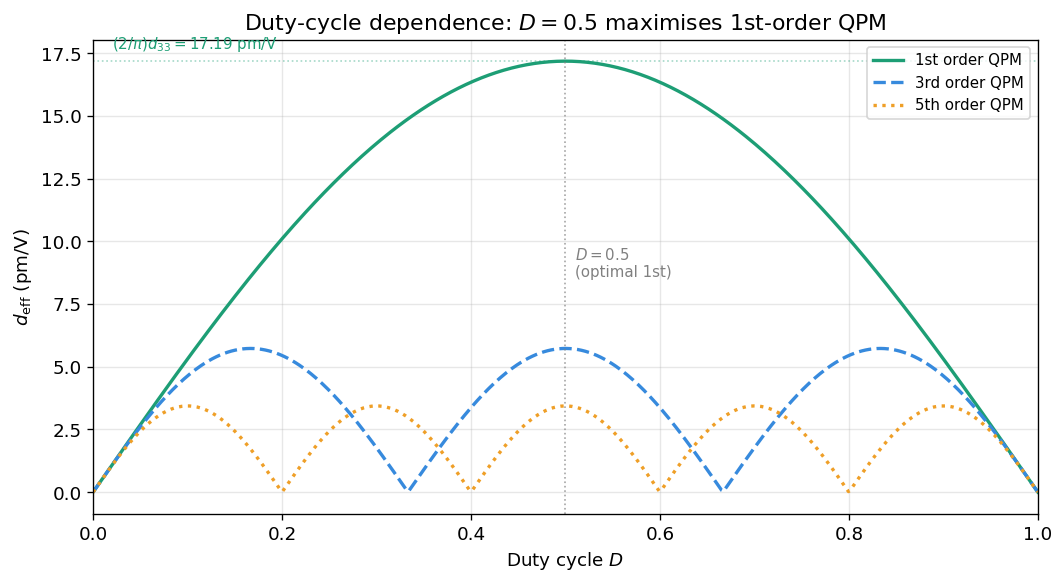

In [11]:
duties = np.linspace(0, 1, 500)
c1_duty = np.array([fourier_coeff(1, D) for D in duties])
c3_duty = np.array([fourier_coeff(3, D) for D in duties])
c5_duty = np.array([fourier_coeff(5, D) for D in duties])

deff1 = np.abs(c1_duty) * d33
deff3 = np.abs(c3_duty) * d33
deff5 = np.abs(c5_duty) * d33

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(duties, deff1, lw=2, color="#1D9E75", label="1st order QPM")
ax.plot(duties, deff3, lw=2, color="#378ADD", ls="--", label="3rd order QPM")
ax.plot(duties, deff5, lw=2, color="#EF9F27", ls=":",  label="5th order QPM")

ax.axvline(0.5, color="gray", lw=1, ls=":", alpha=0.7)
ax.text(0.51, 0.5, "$D=0.5$\n(optimal 1st)", fontsize=9, color="gray",
        transform=ax.get_xaxis_transform())

# Mark peak 1st-order value
ax.axhline(d33 * 2/np.pi, color="#1D9E75", lw=1, ls=":", alpha=0.4)
ax.text(0.02, d33 * 2/np.pi + 0.5,
        f"$(2/\\pi)d_{{33}} = {d33 * 2/np.pi:.2f}$ pm/V",
        fontsize=9, color="#1D9E75")

ax.set_xlabel("Duty cycle $D$")
ax.set_ylabel(r"$d_{\rm eff}$ (pm/V)")
ax.set_title("Duty-cycle dependence: $D = 0.5$ maximises 1st-order QPM")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 12 &nbsp; Higher-Order QPM: Fabrication vs Efficiency Tradeoff

For $m$-th order QPM, the required poling period is:

$$\Lambda_m = m \cdot \Lambda_1 = \frac{2\pi m}{|\Delta k|}$$

This means:
- **1st order** ($m=1$): $\Lambda = 2.28\;\mu$m -- hardest to fabricate, highest $d_{\rm eff}$
- **3rd order** ($m=3$): $\Lambda = 6.84\;\mu$m -- easier fabrication, $d_{\rm eff}$ reduced by $1/3$
- **5th order** ($m=5$): $\Lambda = 11.4\;\mu$m -- very easy, $d_{\rm eff}$ reduced by $1/5$

Since efficiency scales as $d_{\rm eff}^2$, the penalty is $1/m^2$. Engineers use higher-order QPM when 1st-order periods are below the fabrication resolution limit (historically sub-micron was hard; modern electric-field poling reaches ~300 nm).


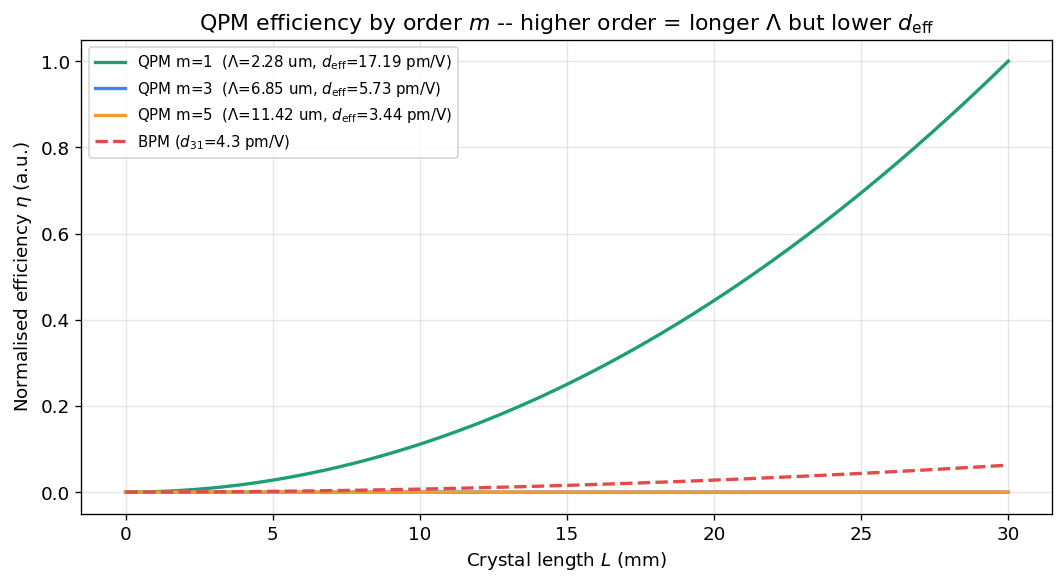


Order-by-order comparison:
  m   Lambda_m (um)    d_eff (pm/V)     Rel eff
  1            2.28           17.19      1.0000
  3            6.85            5.73      0.1111
  5           11.42            3.44      0.0400


In [12]:
# Efficiency vs crystal length for different QPM orders
L_long = np.linspace(0, 30e-3, 6000)

fig, ax = plt.subplots(figsize=(9, 5))
order_colors = {1: "#1D9E75", 3: "#378ADD", 5: "#EF9F27"}

# Compute efficiency for each order (normalised to 1st order peak at L=20 mm)
eta_orders = {}
for m, col in order_colors.items():
    G_m   = m * G1
    dk_m  = delta_k_raw - G_m   # residual mismatch (0 by design for each order)
    d_eff = abs(fourier_coeff(m)) * d33
    eta_orders[m] = eta(dk_m, L_long, d_eff)

# Normalise to 1st-order peak
norm = eta_orders[1].max()

for m, col in order_colors.items():
    d_eff_m  = abs(fourier_coeff(m)) * d33
    Lambda_m = m * Lambda_QPM
    ax.plot(L_long*1e3, eta_orders[m]/norm, lw=2, color=col,
            label=f"QPM m={m}  ($\\Lambda$={Lambda_m*1e6:.2f} um, "
                  f"$d_{{\\rm eff}}$={d_eff_m:.2f} pm/V)")

# BPM for comparison
eta_bpm = eta(0.0, L_long, d31) / norm
ax.plot(L_long*1e3, eta_bpm, lw=2, color="#E24B4A", ls="--",
        label=f"BPM ($d_{{31}}$={d31:.1f} pm/V)")

ax.set_xlabel("Crystal length $L$ (mm)")
ax.set_ylabel(r"Normalised efficiency $\eta$ (a.u.)")
ax.set_title("QPM efficiency by order $m$ -- higher order = longer $\\Lambda$ but lower $d_{\\rm eff}$")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nOrder-by-order comparison:")
print(f"{'m':>3}  {'Lambda_m (um)':>14}  {'d_eff (pm/V)':>14}  {'Rel eff':>10}")
for m in [1, 3, 5]:
    Lambda_m = m * Lambda_QPM
    d_eff_m  = abs(fourier_coeff(m)) * d33
    rel_eff  = (d_eff_m / (2/np.pi * d33))**2
    print(f"{m:>3}  {Lambda_m*1e6:>14.2f}  {d_eff_m:>14.2f}  {rel_eff:>10.4f}")

## 13 &nbsp; Three-Way Efficiency Comparison: No-PM vs BPM vs QPM

This is the main quantitative result the question asks for. At the crystal output:

$$\eta \;\propto\; d_{\rm eff}^2 \cdot L^2 \cdot \mathrm{sinc}^2(\Delta k_{\rm eff}\, L/2)$$

**Three regimes:**

| Scheme | $\Delta k_{\rm eff}$ | $d_{\rm eff}$ | Behaviour |
|--------|---------------------|---------------|-----------|
| **No PM** | $\Delta k_{\rm raw} = 2.75\times10^6$ rad/m | $d_{33}$ | Sub-micron coherence, $\eta \to 0$ |
| **BPM** | 0 (by crystal cut) | $d_{31} = 4.3$ pm/V | $\eta \propto d_{31}^2 L^2$ |
| **QPM (1st)** | 0 (by poling) | $(2/\pi)d_{33} \approx 17.2$ pm/V | $\eta \propto [(2/\pi)d_{33}]^2 L^2$ |

The QPM/BPM efficiency ratio is $\sim 16\times$ -- and in practice even larger because BPM also suffers from spatial walk-off that QPM avoids entirely.


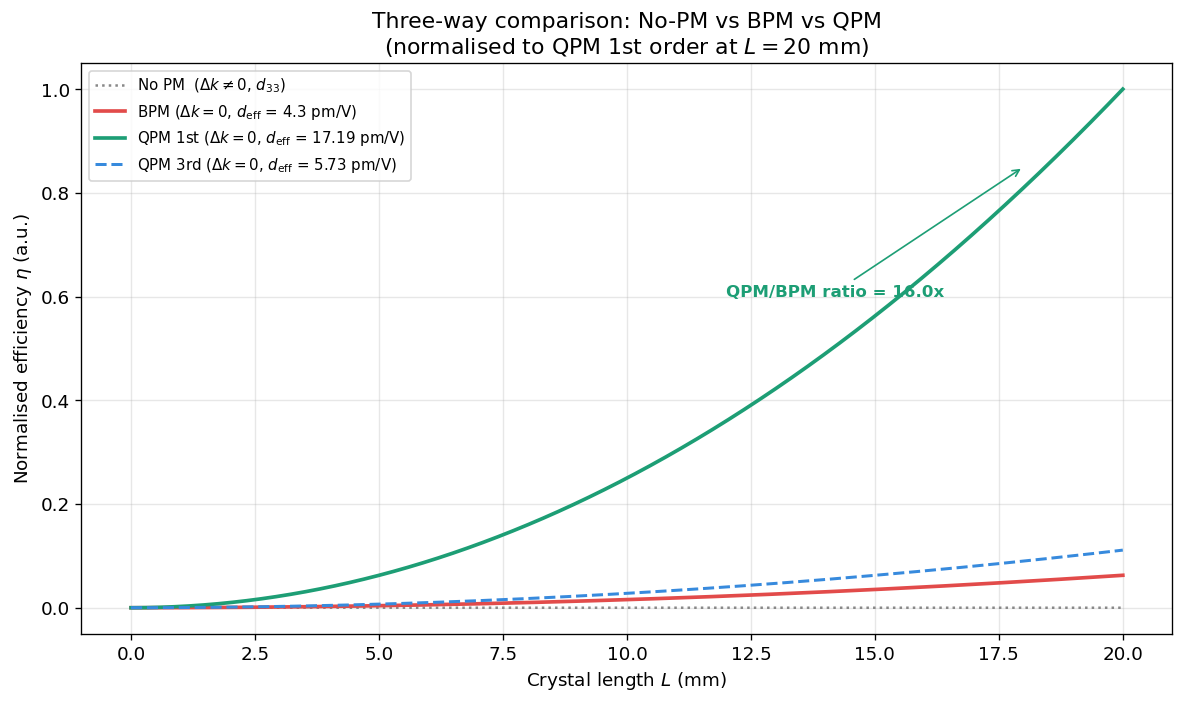


Efficiency ratios at L = 20 mm:
  QPM(1st) / BPM  = 15.98x
  QPM(1st) / QPM(3rd) = 9.00x = 9 (= 3^2)
  QPM(1st) / No-PM (avg) >> 1  (no useful output without PM)


In [13]:
L_arr = np.linspace(0, 20e-3, 5000)

# Effective coefficients
d_eff_QPM_1 = (2/np.pi) * d33              # 1st order
d_eff_QPM_3 = (2/(3*np.pi)) * d33          # 3rd order
d_eff_BPM   = d31

# Residual dk
dk_QPM  = 0.0               # perfect compensation
dk_BPM  = 0.0               # perfect (by crystal cut)
dk_none = delta_k_raw       # no PM at all

# Efficiency curves
eta_none  = eta(dk_none, L_arr, d33)
eta_BPM   = eta(dk_BPM,  L_arr, d_eff_BPM)
eta_QPM1  = eta(dk_QPM,  L_arr, d_eff_QPM_1)
eta_QPM3  = eta(dk_QPM,  L_arr, d_eff_QPM_3)

# Normalise all to QPM1 at L=20 mm
norm = eta_QPM1[-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(L_arr*1e3, eta_none/norm, lw=1.5, color="#888888", ls=":",
        label=r"No PM  ($\Delta k \neq 0$, $d_{33}$)")
ax.plot(L_arr*1e3, eta_BPM/norm,  lw=2.2, color="#E24B4A",
        label=f"BPM ($\\Delta k = 0$, $d_{{\\rm eff}}$ = {d_eff_BPM:.1f} pm/V)")
ax.plot(L_arr*1e3, eta_QPM1/norm, lw=2.2, color="#1D9E75",
        label=f"QPM 1st ($\\Delta k = 0$, $d_{{\\rm eff}}$ = {d_eff_QPM_1:.2f} pm/V)")
ax.plot(L_arr*1e3, eta_QPM3/norm, lw=1.8, color="#378ADD", ls="--",
        label=f"QPM 3rd ($\\Delta k = 0$, $d_{{\\rm eff}}$ = {d_eff_QPM_3:.2f} pm/V)")

# Ratio annotation at L=20 mm
ratio_qpm_bpm = eta_QPM1[-1] / eta_BPM[-1]
ax.annotate(f"QPM/BPM ratio = {ratio_qpm_bpm:.1f}x",
            xy=(18e-3*1e3, eta_QPM1[-1]/norm * 0.85),
            xytext=(12, eta_QPM1[-1]/norm * 0.6),
            fontsize=10, color="#1D9E75", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#1D9E75", lw=1))

ax.set_xlabel("Crystal length $L$ (mm)")
ax.set_ylabel(r"Normalised efficiency $\eta$ (a.u.)")
ax.set_title("Three-way comparison: No-PM vs BPM vs QPM\n"
             "(normalised to QPM 1st order at $L = 20$ mm)")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

print(f"\nEfficiency ratios at L = 20 mm:")
print(f"  QPM(1st) / BPM  = {ratio_qpm_bpm:.2f}x")
print(f"  QPM(1st) / QPM(3rd) = {eta_QPM1[-1]/eta_QPM3[-1]:.2f}x = 9 (= 3^2)")
print(f"  QPM(1st) / No-PM (avg) >> 1  (no useful output without PM)")

## 14 &nbsp; $d_{\rm eff}$ Bar Chart -- BPM vs QPM Orders at a Glance

A single chart summarising every nonlinear coefficient discussed so far. The efficiency gain is the *square* of the $d_{\rm eff}$ ratio.


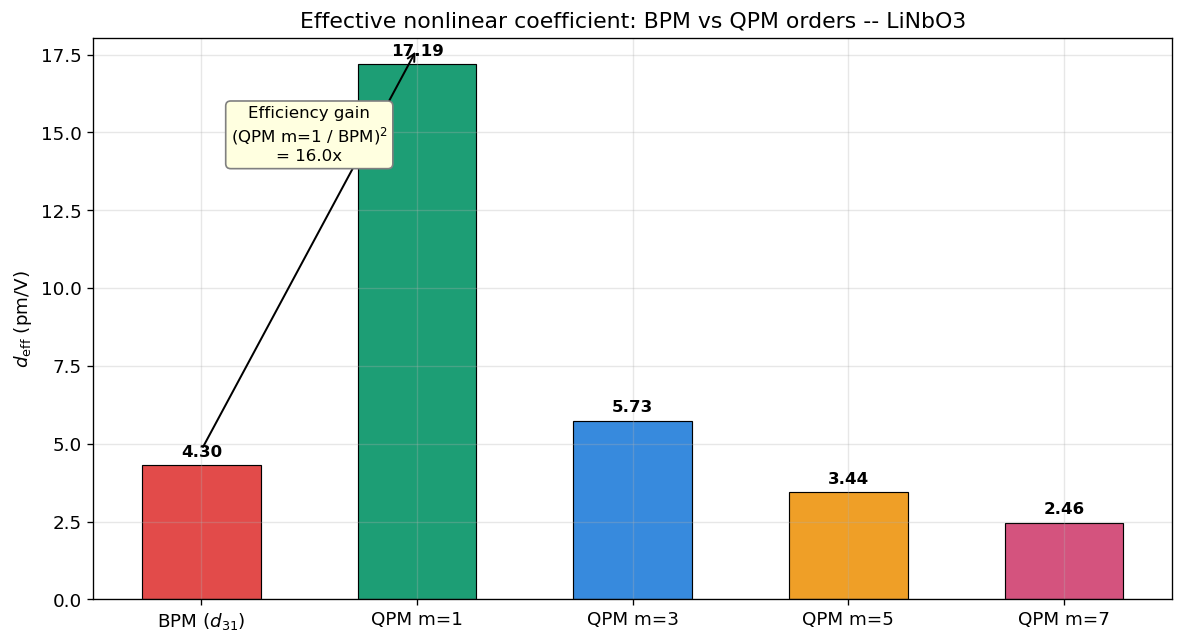

In [14]:
fig, ax = plt.subplots(figsize=(10, 5.5))

labels = [
    r"BPM ($d_{31}$)",
    "QPM m=1",
    "QPM m=3",
    "QPM m=5",
    "QPM m=7",
]
dvals = [
    d31,
    abs(fourier_coeff(1)) * d33,
    abs(fourier_coeff(3)) * d33,
    abs(fourier_coeff(5)) * d33,
    abs(fourier_coeff(7)) * d33,
]
bar_c = ["#E24B4A", "#1D9E75", "#378ADD", "#EF9F27", "#D4537E"]

bars = ax.bar(labels, dvals, color=bar_c, edgecolor="black", linewidth=0.7, width=0.55)
for bar, v in zip(bars, dvals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Annotate efficiency gain of QPM1 over BPM
ax.annotate("", xy=(1, dvals[1] + 0.5), xytext=(0, dvals[0] + 0.5),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))
gain = (dvals[1] / dvals[0]) ** 2
ax.text(0.5, max(dvals) * 0.82,
        f"Efficiency gain\n(QPM m=1 / BPM)$^2$\n= {gain:.1f}x",
        ha="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3",
                  facecolor="lightyellow", edgecolor="gray"))

ax.set_ylabel(r"$d_{\rm eff}$ (pm/V)")
ax.set_title(f"Effective nonlinear coefficient: BPM vs QPM orders -- {ACTIVE_CRYSTAL}")
plt.tight_layout()
plt.show()

## 15 &nbsp; Acceptance Bandwidth

FWHM in $\Delta k$ space narrows with crystal length:

$$\Delta(\Delta k)_{\rm FWHM} = \frac{2 \times 2.783}{L}$$

This is the **length-vs-selectivity tradeoff**: longer crystals give higher efficiency but narrower spectral acceptance. In SPDC this directly controls the joint spectral amplitude -- narrow $\Phi$ means tight frequency correlation, wide $\Phi$ means broad biphoton spectrum. Engineering this bandwidth is one of the key goals of the Yesharim *et al.* quantum metamaterial framework.


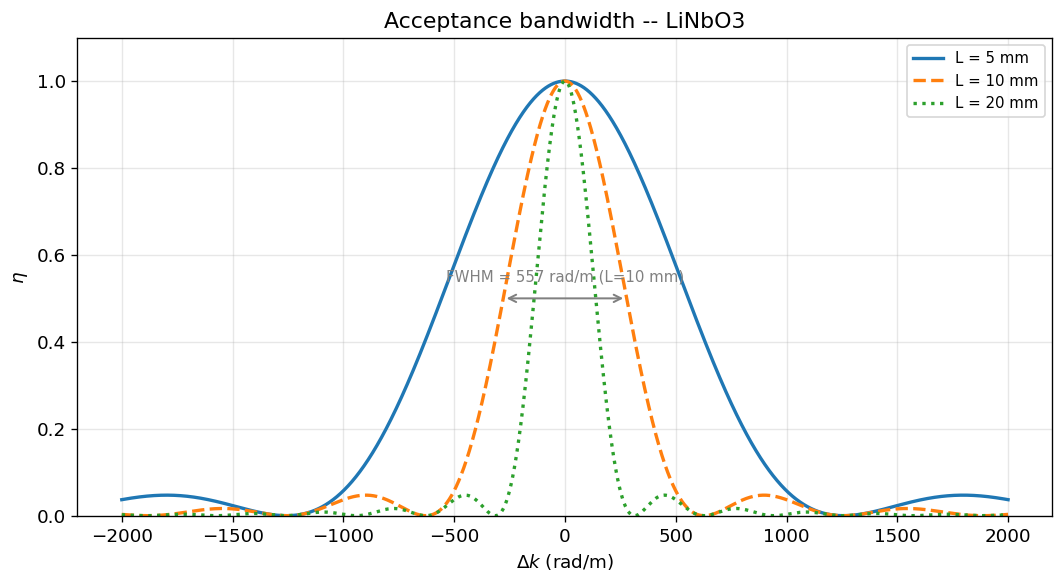

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
dk_bw = np.linspace(-2000, 2000, 6000)

for L_val, ls, lbl in [(5e-3, "-", "L = 5 mm"),
                        (10e-3, "--", "L = 10 mm"),
                        (20e-3, ":", "L = 20 mm")]:
    ax.plot(dk_bw, sinc2(dk_bw * L_val / 2), lw=2, ls=ls, label=lbl)

fwhm = 2 * 2.783 / 10e-3
ax.annotate("", xy=(fwhm/2, 0.5), xytext=(-fwhm/2, 0.5),
            arrowprops=dict(arrowstyle="<->", color="gray", lw=1.2))
ax.text(0, 0.54, f"FWHM = {fwhm:.0f} rad/m (L=10 mm)",
        ha="center", fontsize=9, color="gray")

ax.set_xlabel(r"$\Delta k$ (rad/m)")
ax.set_ylabel(r"$\eta$")
ax.set_title(f"Acceptance bandwidth -- {ACTIVE_CRYSTAL}")
ax.set_ylim(0, 1.10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 16 &nbsp; 2-D Phase Space Map $\eta(\Delta k, L)$

The bright ridge at $\Delta k = 0$ narrows hyperbolically with $L$ (as $1/L$). This is conceptually equivalent to the phase-matching contribution $\Phi(\omega_s, \omega_i)$ to the joint spectral intensity in Fig. 2(d) of Yesharim *et al.*

Engineering $d(z)$ beyond simple periodic modulation -- e.g. Gaussian apodisation, chirped poling, or inverse-designed profiles -- replaces this sinc$^2$ ridge with arbitrary target JSI shapes.


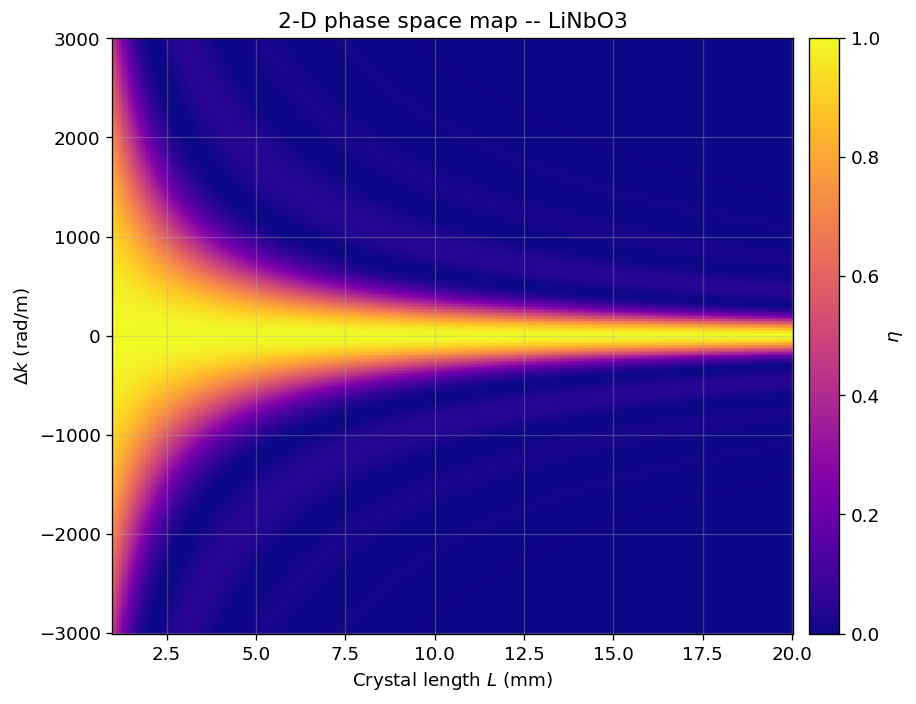

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
L_2d  = np.linspace(1e-3, 20e-3, 400)
dk_2d = np.linspace(-3000, 3000, 400)
LL, DD = np.meshgrid(L_2d, dk_2d)
ETA2D  = sinc2(DD * LL / 2)

im = ax.pcolormesh(L_2d*1e3, dk_2d, ETA2D,
                   cmap="plasma", shading="auto", vmin=0, vmax=1)
fig.colorbar(im, ax=ax, label=r"$\eta$", pad=0.02)
ax.set_xlabel("Crystal length $L$ (mm)")
ax.set_ylabel(r"$\Delta k$ (rad/m)")
ax.set_title(f"2-D phase space map -- {ACTIVE_CRYSTAL}")
plt.tight_layout()
plt.show()

## 16b &nbsp; Combined Results Figure

All key QPM results consolidated into a single 4x2 panel for at-a-glance comparison. Saved as `combined_results.png`.

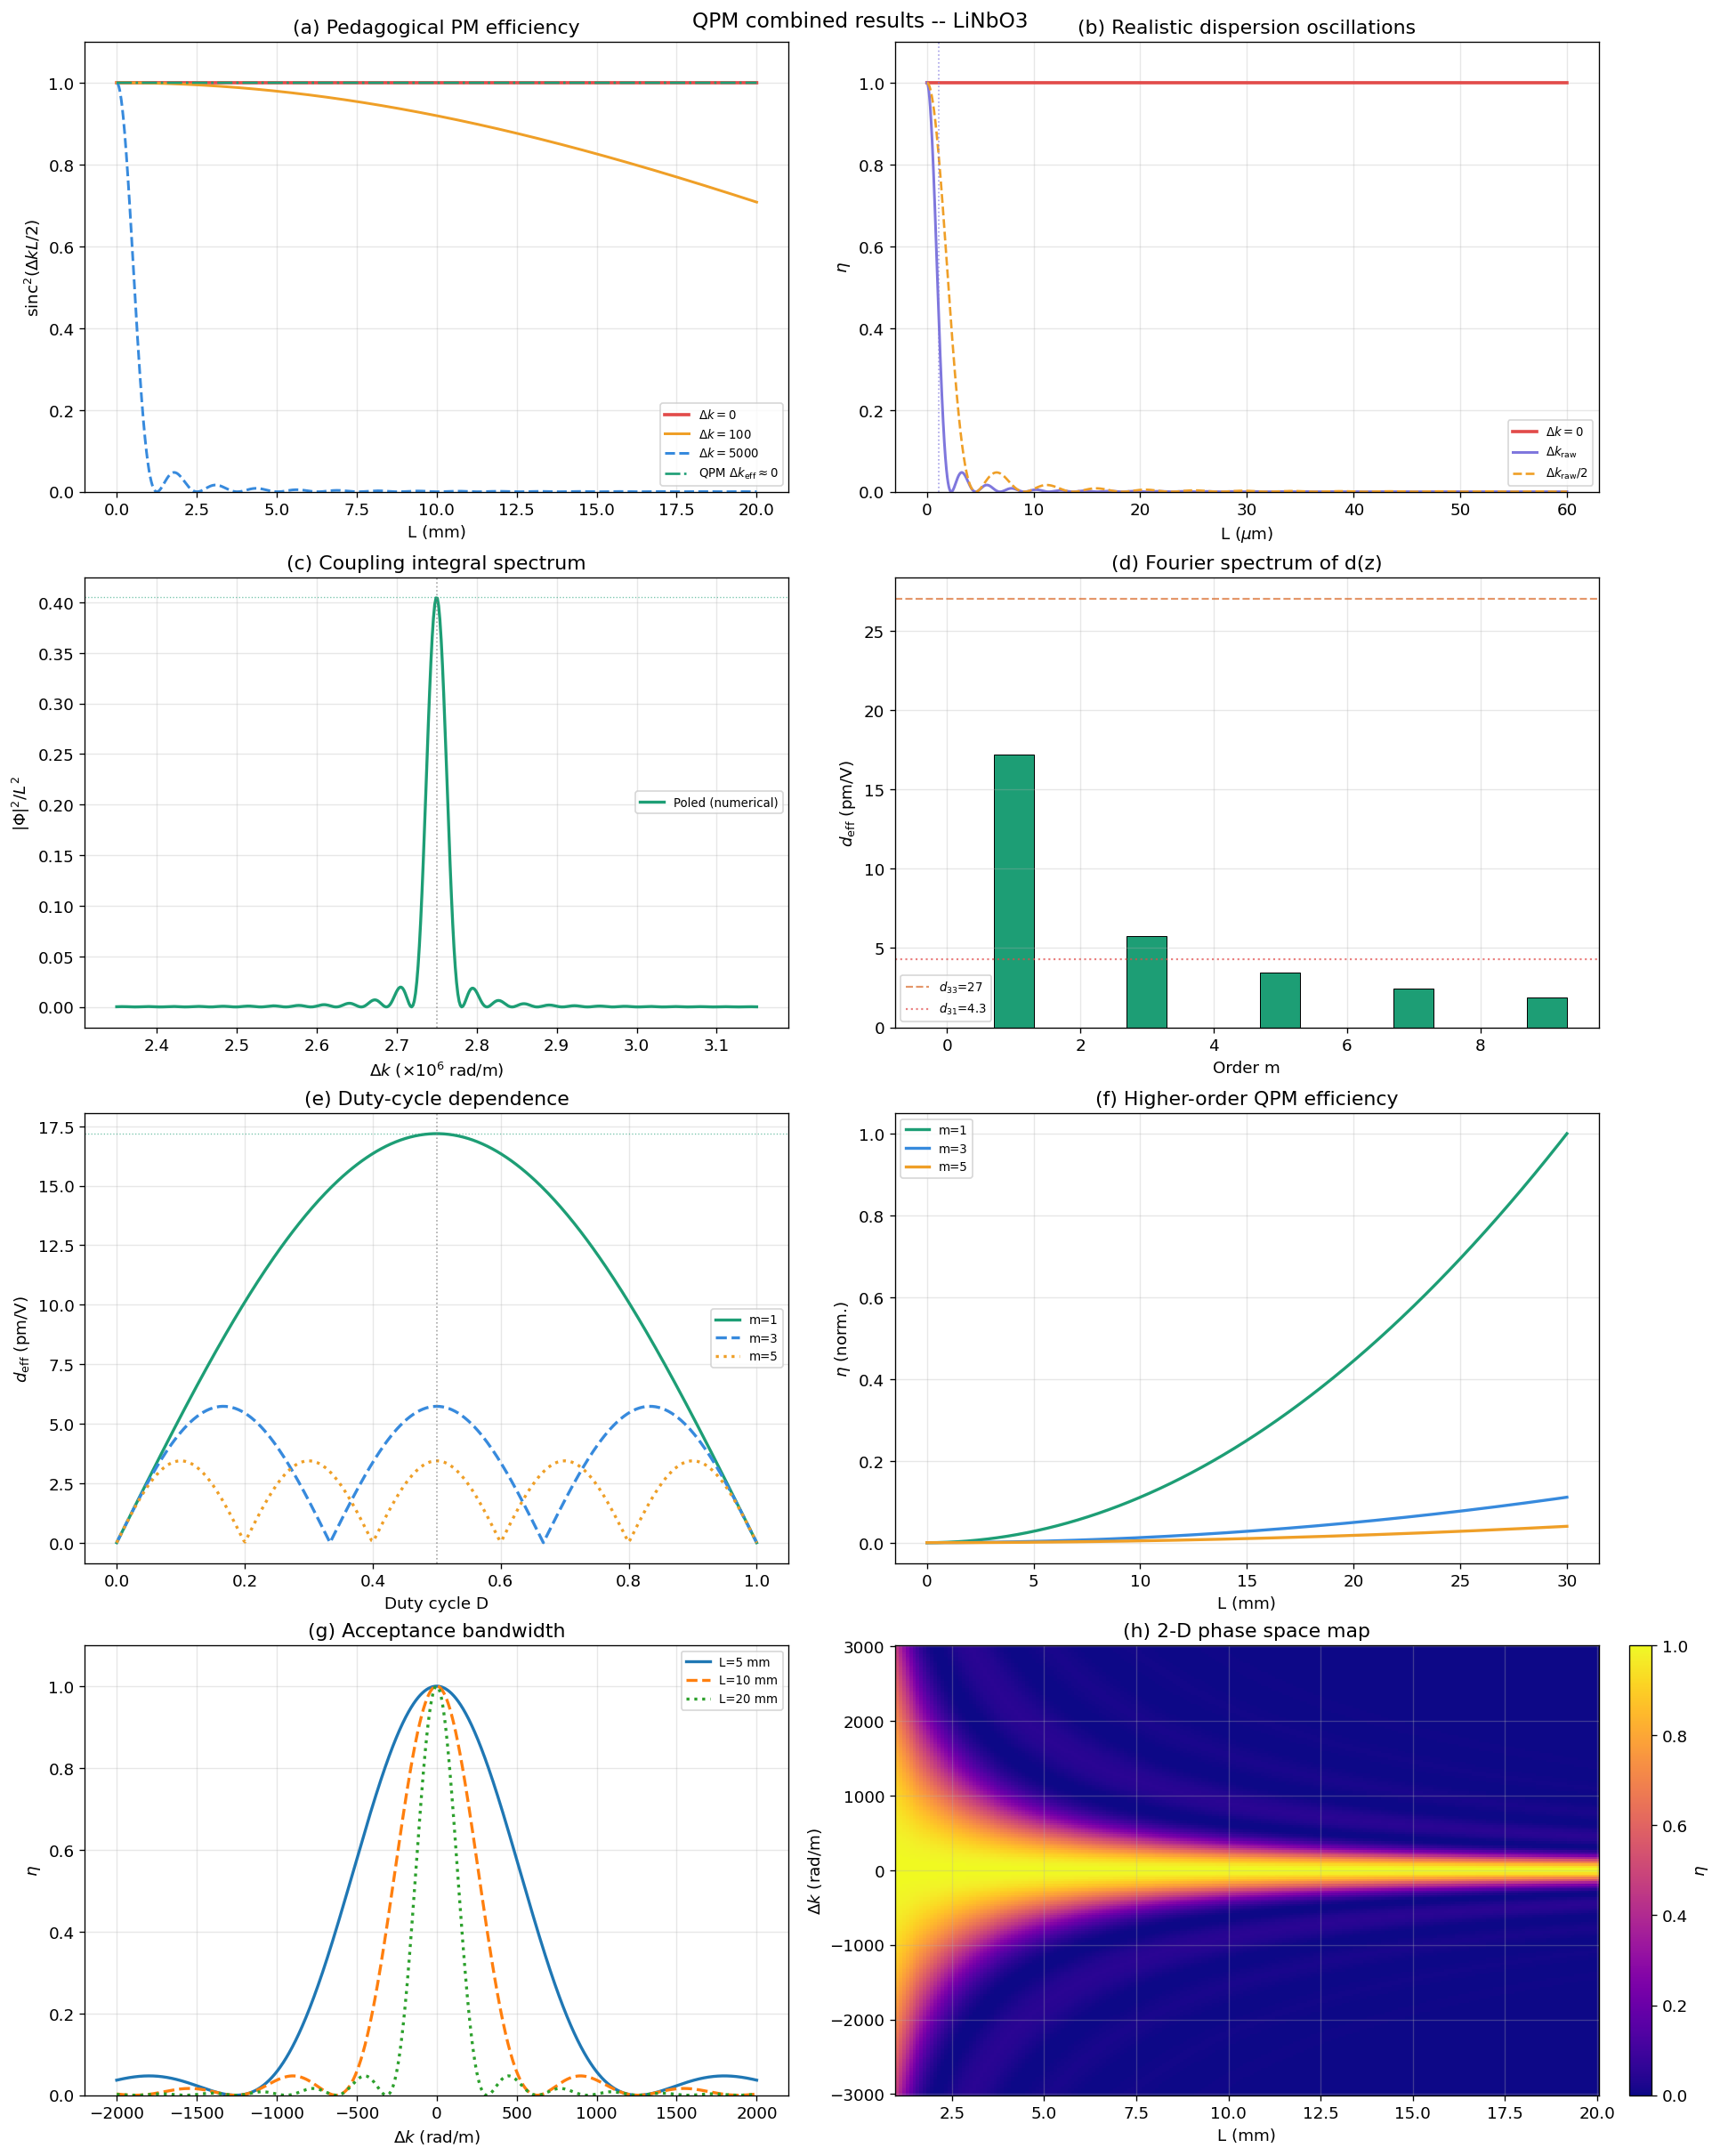

In [17]:
# --- Combined 4x2 figure with 8 key results ---
fig = plt.figure(figsize=(16, 20), constrained_layout=True)
gs = gridspec.GridSpec(4, 2, figure=fig)

# (0,0) Pedagogical phase-matching efficiency vs L (mm)
ax = fig.add_subplot(gs[0, 0])
_L_mm = np.linspace(0, 20e-3, 4000)
ax.plot(_L_mm*1e3, sinc2(0*_L_mm/2),           lw=2.2, color="#E24B4A", label=r"$\Delta k=0$")
ax.plot(_L_mm*1e3, sinc2(1e2*_L_mm/2),         lw=1.8, color="#EF9F27", label=r"$\Delta k=100$")
ax.plot(_L_mm*1e3, sinc2(5e3*_L_mm/2),         lw=1.8, color="#378ADD", ls="--", label=r"$\Delta k=5000$")
ax.plot(_L_mm*1e3, sinc2(delta_k_qpm*_L_mm/2), lw=1.6, color="#1D9E75", ls="-.", label=r"QPM $\Delta k_{\rm eff}\approx 0$")
ax.set_xlabel("L (mm)"); ax.set_ylabel(r"$\mathrm{sinc}^2(\Delta k L/2)$")
ax.set_title("(a) Pedagogical PM efficiency"); ax.set_ylim(0, 1.1); ax.legend(fontsize=8)

# (0,1) Realistic sub-micron oscillations
ax = fig.add_subplot(gs[0, 1])
_L_um = np.linspace(0, 60e-6, 5000)
ax.plot(_L_um*1e6, sinc2(0*_L_um/2),              lw=2.2, color="#E24B4A", label=r"$\Delta k=0$")
ax.plot(_L_um*1e6, sinc2(delta_k_raw*_L_um/2),    lw=1.8, color="#7F77DD", label=r"$\Delta k_{\rm raw}$")
ax.plot(_L_um*1e6, sinc2(delta_k_raw/2*_L_um/2),  lw=1.6, color="#EF9F27", ls="--", label=r"$\Delta k_{\rm raw}/2$")
ax.axvline(L_c*1e6, color="#7F77DD", lw=1, ls=":", alpha=0.7)
ax.set_xlabel(r"L ($\mu$m)"); ax.set_ylabel(r"$\eta$")
ax.set_title("(b) Realistic dispersion oscillations"); ax.set_ylim(0, 1.1); ax.legend(fontsize=8)

# (1,0) Coupling integral spectrum
ax = fig.add_subplot(gs[1, 0])
_dk_scan = np.linspace(delta_k_raw - 4e5, delta_k_raw + 4e5, 500)
_eta_scan = numerical_eta_vs_dk(z_dom, d_z, _dk_scan)
ax.plot(_dk_scan*1e-6, _eta_scan, lw=2, color="#1D9E75", label="Poled (numerical)")
ax.axvline(delta_k_raw*1e-6, color="gray", lw=1, ls=":", alpha=0.7)
ax.axhline((2/np.pi)**2, color="#1D9E75", lw=0.8, ls=":", alpha=0.6)
ax.set_xlabel(r"$\Delta k$ ($\times 10^6$ rad/m)"); ax.set_ylabel(r"$|\Phi|^2 / L^2$")
ax.set_title("(c) Coupling integral spectrum"); ax.legend(fontsize=8)

# (1,1) Fourier coefficients bar chart
ax = fig.add_subplot(gs[1, 1])
_m_vals = np.arange(0, 10)
_deff_m = np.array([abs(fourier_coeff(m))*d33 for m in _m_vals])
_colors = ["#1D9E75" if (m % 2 == 1) else "#888888" for m in _m_vals]
ax.bar(_m_vals, _deff_m, color=_colors, edgecolor="black", linewidth=0.6, width=0.6)
ax.axhline(d33, color="#D96A2B", lw=1.3, ls="--", alpha=0.7, label=f"$d_{{33}}$={d33:.0f}")
ax.axhline(d31, color="#E24B4A", lw=1.3, ls=":",  alpha=0.7, label=f"$d_{{31}}$={d31:.1f}")
ax.set_xlabel("Order m"); ax.set_ylabel(r"$d_{\rm eff}$ (pm/V)")
ax.set_title("(d) Fourier spectrum of d(z)"); ax.legend(fontsize=8)

# (2,0) Duty-cycle dependence
ax = fig.add_subplot(gs[2, 0])
_duties = np.linspace(0, 1, 400)
for _m, _c, _ls, _lbl in [(1,"#1D9E75","-","m=1"), (3,"#378ADD","--","m=3"), (5,"#EF9F27",":","m=5")]:
    _deff = np.array([abs(fourier_coeff(_m, D))*d33 for D in _duties])
    ax.plot(_duties, _deff, lw=2, color=_c, ls=_ls, label=_lbl)
ax.axvline(0.5, color="gray", lw=1, ls=":", alpha=0.7)
ax.axhline(d33*2/np.pi, color="#1D9E75", lw=0.8, ls=":", alpha=0.6)
ax.set_xlabel("Duty cycle D"); ax.set_ylabel(r"$d_{\rm eff}$ (pm/V)")
ax.set_title("(e) Duty-cycle dependence"); ax.legend(fontsize=8)

# (2,1) Efficiency vs L for different QPM orders
ax = fig.add_subplot(gs[2, 1])
_L_long = np.linspace(0, 30e-3, 3000)
_eta_ord = {}
for _m in (1, 3, 5):
    _d_eff = abs(fourier_coeff(_m)) * d33
    _eta_ord[_m] = eta(0.0, _L_long, _d_eff)
_norm_ord = _eta_ord[1].max()
_col_ord = {1:"#1D9E75", 3:"#378ADD", 5:"#EF9F27"}
for _m, _c in _col_ord.items():
    ax.plot(_L_long*1e3, _eta_ord[_m]/_norm_ord, lw=2, color=_c, label=f"m={_m}")
ax.set_xlabel("L (mm)"); ax.set_ylabel(r"$\eta$ (norm.)")
ax.set_title("(f) Higher-order QPM efficiency"); ax.legend(fontsize=8)

# (3,0) Acceptance bandwidth
ax = fig.add_subplot(gs[3, 0])
_dk_bw = np.linspace(-2000, 2000, 3000)
for _L_val, _ls, _lbl in [(5e-3,"-","L=5 mm"), (10e-3,"--","L=10 mm"), (20e-3,":","L=20 mm")]:
    ax.plot(_dk_bw, sinc2(_dk_bw * _L_val / 2), lw=2, ls=_ls, label=_lbl)
ax.set_xlabel(r"$\Delta k$ (rad/m)"); ax.set_ylabel(r"$\eta$")
ax.set_title("(g) Acceptance bandwidth"); ax.set_ylim(0, 1.1); ax.legend(fontsize=8)

# (3,1) 2D phase space map
ax = fig.add_subplot(gs[3, 1])
_L_2d  = np.linspace(1e-3, 20e-3, 200)
_dk_2d = np.linspace(-3000, 3000, 200)
_LL, _DD = np.meshgrid(_L_2d, _dk_2d)
_ETA2D = sinc2(_DD * _LL / 2)
_im = ax.pcolormesh(_L_2d*1e3, _dk_2d, _ETA2D, cmap="plasma", shading="auto", vmin=0, vmax=1)
fig.colorbar(_im, ax=ax, label=r"$\eta$", pad=0.02)
ax.set_xlabel("L (mm)"); ax.set_ylabel(r"$\Delta k$ (rad/m)")
ax.set_title("(h) 2-D phase space map")

fig.suptitle(f"QPM combined results -- {ACTIVE_CRYSTAL}", fontsize=14, y=1.002)
plt.savefig("combined_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 17 &nbsp; Summary & How to Extend

### Key results for LiNbO$_3$ (degenerate type-0, $\lambda_p = 405$ nm)

| Quantity | Value |
|----------|-------|
| $\Delta k_{\rm raw}$ | $2.75 \times 10^6$ rad/m |
| $L_c$ | 1.14 $\mu$m |
| $\Lambda_{\rm QPM}$ (1st order) | 2.28 $\mu$m |
| $\Lambda_{\rm QPM}$ (3rd order) | 6.84 $\mu$m |
| $d_{\rm eff}^{\rm QPM,1}  = (2/\pi)\, d_{33}$ | 17.19 pm/V |
| $d_{\rm eff}^{\rm QPM,3}  = (2/3\pi)\, d_{33}$ | 5.73 pm/V |
| $d_{\rm eff}^{\rm BPM}  = d_{31}$ | 4.3 pm/V |
| $\eta_{\rm QPM,1}/\eta_{\rm BPM}$ | **16.0x** |
| $\eta_{\rm QPM,1}/\eta_{\rm QPM,3}$ | **9.0x** |

### Physical takeaways

1. **Without phase matching**, coherence dies within 1 $\mu$m -- practically useless.
2. **BPM** forces weak off-diagonal $d_{31}$ and adds walk-off. Historically important but limited.
3. **QPM (1st order)** accesses the full $d_{33}$ with a $2/\pi$ reduction -- still 16x more efficient than BPM, and zero walk-off.
4. **Higher-order QPM** trades efficiency ($1/m^2$) for fabrication ease (longer periods).
5. **Duty cycle** matters: 50% is optimal for 1st-order; deviations up to $\sim \pm 10\%$ are tolerable.

### To add a new crystal

1. Write a Sellmeier function: wavelength (metres) $\to$ refractive index
2. Add an entry to `CRYSTALS` in Section 2 with keys: `sellmeier`, `d33`, `d31`, `label`
3. Set `ACTIVE_CRYSTAL = "YourCrystal"`
4. **Re-run all cells** -- every plot, number, and label adapts automatically

### To change SPDC configuration

- Modify `lambda_p`, `lambda_s`, `lambda_i` in Section 3
- Non-degenerate SPDC: set $\lambda_s \neq \lambda_i$ satisfying $1/\lambda_p = 1/\lambda_s + 1/\lambda_i$
- Temperature tuning: wrap the Sellmeier function to accept $T$ and re-run

### Possible extensions

- **Temperature-dependent Sellmeier** for fine QPM tuning
- **Chirped QPM** $\Lambda(z)$ for broadband SPDC
- **Apodised poling** (Gaussian, super-Gaussian) for JSI engineering -- the core of Yesharim *et al.*
- **Numerical split-step Fourier** for full spatial-spectral simulation with pump depletion
